# K-means Clustering
En este proyecto, se implementa un modelo de K-means Clustering para segmentar clientes en función de sus comportamientos de compra y otros factores relevantes. El objetivo es identificar diferentes segmentos de clientes para aplicar estrategias de marketing personalizadas. A continuación, se describen los pasos principales del proyecto:

1. **Definición de Criterios para los Segmentos**:
    - **Bajo Valor**: Clientes con baja frecuencia de compra, bajo valor medio de orden y alta probabilidad de churn.
    - **Medio Valor**: Clientes con valores moderados en frecuencia de compra y valor medio de orden.
    - **Alto Valor**: Clientes con alta frecuencia de compra, alto valor medio de orden, y baja probabilidad de churn.
 
2. **Importación de Librerías**:
    - Se importan las librerías necesarias como pandas, numpy, seaborn, matplotlib, sklearn, entre otras.
 
3. **Preparación del Dataset**:
    - Se cargan los datos preparados para el modelo desde un archivo CSV.
    - Se verifica la integridad de los datos y se manejan valores nulos.
 
4. **Procesamiento y Normalización de Datos**:
    - Se reemplazan valores nulos y se filtran clientes según ciertos umbrales.
    - Se seleccionan características relevantes para el clustering y se normalizan.
 
5. **Método del Codo**:
    - Se utiliza el método del codo para determinar el número óptimo de clústeres.
 
6. **Entrenamiento del Modelo**:
    - Se entrena el modelo K-means con el número óptimo de clústeres.
    - Se asignan segmentos a los clientes y se exportan los resultados a un archivo CSV.
 
7. **Visualización de Resultados**:
    - Se reducen las dimensiones a dos componentes principales y se grafican los clústeres generados.
 
8. **Exportación del Modelo Entrenado**:
    - Se guardan el modelo K-means entrenado y el scaler utilizado para normalizar los datos.
 
Este flujo de trabajo permite segmentar a los clientes de manera efectiva, facilitando la implementación de estrategias de marketing más precisas y personalizadas

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
import joblib
from matplotlib import cm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## Preparación del Dataset
Extraeremos los datos preparados para el modelo

In [31]:
# Leer los datos preparados
data = pd.read_csv(r"C:\Users\Sr. Sebastian\Documents\GitHub\CRMIA\app\ia\segments\Data\X_kmeans_data.csv")

# Definir la ruta base para guardar archivos
ruta_base = os.path.join('Data')

# Mostrar las primeras filas
print("Datos cargados para K-Means Clustering:")
print(data.columns)

# Verificar si el conjunto de datos tiene problemas generales
print("\n¿El conjunto de datos contiene algún valor inválido?")
print(data.isnull().values.any() or np.isinf(data).values.any())

Datos cargados para K-Means Clustering:
Index(['id', 'total_compras', 'frecuencia_compra', 'dias_ultima_compra',
       'valor_medio_orden', 'probabilidad_churn', 'valor_cliente'],
      dtype='object')

¿El conjunto de datos contiene algún valor inválido?
False


## Procesar y Normalizar los Datos 
Estandarizaremos las características para garantizar que todas las métricas tengan el mismo peso en el modelo.

In [32]:
# Reemplazar valores nulos
data.fillna(0, inplace=True)

# Filtros de clientes para el entrenamiento del modelo
CHURN_THRESHOLD = 0.65
DAYS_LAST_PURCHASE_THRESHOLD = 90

low_value_df = data[(data['probabilidad_churn'] > CHURN_THRESHOLD) | (data['dias_ultima_compra'] > DAYS_LAST_PURCHASE_THRESHOLD)]
no_churn_df = data[(data['probabilidad_churn'] <= CHURN_THRESHOLD) & (data['dias_ultima_compra'] <= DAYS_LAST_PURCHASE_THRESHOLD)]

# Seleccionar características para el clustering
features = ['total_compras', 'frecuencia_compra', 'dias_ultima_compra']
X = no_churn_df[features]

print(f"Número de clientes en 'no_churn_df': {len(no_churn_df)}")

# Normalizar las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Crear un DataFrame con las características normalizadas
features_scaled_df = pd.DataFrame(X_scaled, columns=features)

# Confirmar estadísticas de los datos escalados
print("Datos normalizados y ponderados:")
print(features_scaled_df.head())

Número de clientes en 'no_churn_df': 86
Datos normalizados y ponderados:
   total_compras  frecuencia_compra  dias_ultima_compra
0       3.247517           0.055592            1.186884
1      -0.227969          -0.819511           -0.521639
2      -0.317084          -0.913448            0.112955
3       0.395836          -0.483313            1.089254
4       0.841411          -0.720629           -0.619268


## Método del Codo
Asignarle el numero de clusters (`10 optimo para ver el codigo`) y observar su comportamiento

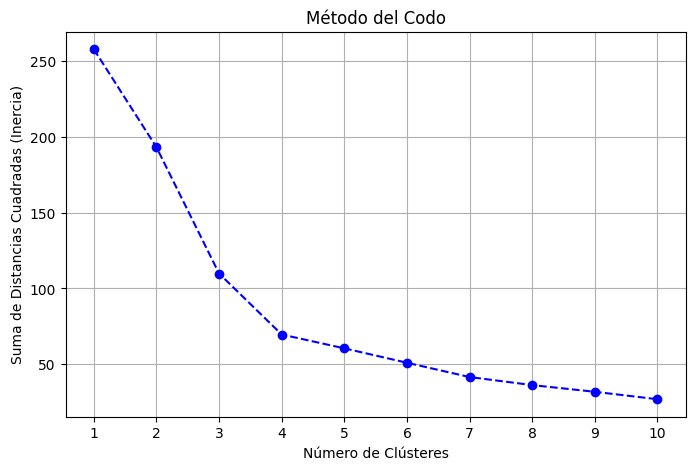

In [33]:
# Calcular la inercia para diferentes números de clústeres
inertia = []  # Lista para almacenar la inercia
range_clusters = range(1, 11)  # Rango de números de clústeres para el método codo

for k in range_clusters:
    # Crear y entrenar el modelo K-Means
    kmeans = KMeans(n_clusters=k, random_state=42)  # Semilla para reproducibilidad
    kmeans.fit(X_scaled)  # `X_scaled` es el conjunto de datos normalizados
    inertia.append(kmeans.inertia_)  # Almacenar la inercia para el valor actual de k

# Calcular la caída relativa de inercia
inertia_diffs = np.diff(inertia)
optimal_clusters = np.argmax(inertia_diffs) + 2  # Sumar 2 porque np.diff reduce el índice en 1

# Graficar el método del codo
plt.figure(figsize=(8, 5))
plt.plot(range_clusters, inertia, marker='o', linestyle='--', color='b')
plt.xlabel('Número de Clústeres')
plt.ylabel('Suma de Distancias Cuadradas (Inercia)')
plt.title('Método del Codo')
plt.xticks(range_clusters)
plt.grid()
plt.show()

## Entrenamiento del Modelo
Asignamos 3 clústeres basado en los criterios de la aplicacion WEB CRM
- Alto valor
- Medio valor
- Bajo valor

In [34]:
# Método del codo (opcional, si no se ha calculado previamente)
optimal_clusters = 3  # Determinado previamente

# Entrenar el modelo K-Means
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
no_churn_df = no_churn_df.copy()
no_churn_df.loc[:, 'segmento'] = kmeans.fit_predict(X_scaled)

# Asignar segmento bajo valor (0) a clientes excluidos
low_value_df = low_value_df.copy()
low_value_df.loc[:, 'segmento'] = 0

# Verificar distribución de segmentos
final_df = pd.concat([no_churn_df, low_value_df], ignore_index=True)
print("\nTamaño de cada segmento:")
print(final_df['segmento'].value_counts())

# Construir la ruta completa para el archivo CSV
ruta_csv = os.path.join(ruta_base, 'kmeans_segmented_results.csv')

# Exportar el DataFrame a CSV
final_df.to_csv(ruta_csv, index=False)
print(f"\nSegmentación completa. Resultados exportados a: {ruta_csv}")



Tamaño de cada segmento:
segmento
0    530
1     57
2     11
Name: count, dtype: int64

Segmentación completa. Resultados exportados a: Data\kmeans_segmented_results.csv


##  Visualizar Resultados
## Interpretación del Gráfico de Clústeres
 
El gráfico generado muestra la visualización de los clústeres en dos componentes principales, que son el resultado de aplicar PCA (Análisis de Componentes Principales) a las características normalizadas.

 - **Eje X (Componente Principal 1)**: Representa la primera componente principal, que es la dirección en la que los datos varían más. Esta componente captura la mayor parte de la variabilidad en los datos.
 - **Eje Y (Componente Principal 2)**: Representa la segunda componente principal, que es ortogonal a la primera y captura la segunda mayor parte de la variabilidad en los datos.
 - **Puntos en el Gráfico**: Cada punto en el gráfico representa un cliente, proyectado en el espacio de las dos componentes principales.
 - **Colores de los Puntos**: Los colores de los puntos indican el segmento al que pertenece cada cliente. Cada color representa un clúster diferente.
 - **Interpretación de los Clústeres**: Los clústeres se pueden interpretar observando la agrupación de puntos de colores similares. Los clientes dentro del mismo clúster tienen comportamientos de compra similares según las características utilizadas para el clustering.

Este gráfico ayuda a visualizar cómo se agrupan los clientes en diferentes segmentos y facilita la identificación de patrones y diferencias entre los segmentos.

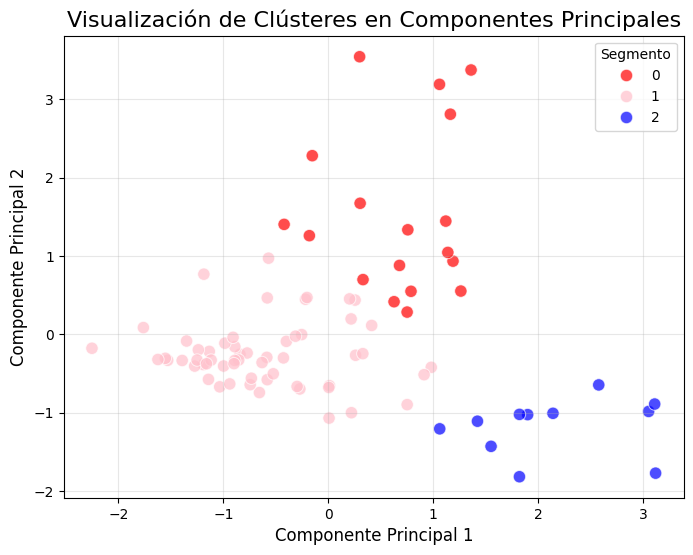

In [35]:
# Reducir dimensiones a 2 componentes principales
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)

# Crear un DataFrame con las características PCA
pca_df = pd.DataFrame(pca_features, columns=['PCA1', 'PCA2'])
pca_df['segmento'] = final_df['segmento']

# Definir colores manualmente para cada segmento
segment_colors = {
    0: 'red',    # Bajo valor
    1: 'pink',   # Medio valor
    2: 'blue'    # Alto valor
}

# Graficar los clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='segmento',
    palette=segment_colors,
    data=pca_df,
    alpha=0.7,
    s=80
)

# Configuración del gráfico
plt.title('Visualización de Clústeres en Componentes Principales', fontsize=16)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.legend(title='Segmento', loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

## Exportamos el Modelo K-Means Entrenado

In [36]:
# Asegurarse de que el directorio existe
os.makedirs(ruta_base, exist_ok=True)

# Construir las rutas completas para los archivos
ruta_modelo = os.path.join(ruta_base, 'kmeans_model.pkl')
ruta_scaler = os.path.join(ruta_base, 'kmeans_scaler.pkl')

# Guardar el modelo y el scaler
joblib.dump(kmeans, ruta_modelo)
joblib.dump(scaler, ruta_scaler)

print(f"Modelo guardado en: {ruta_modelo}")
print(f"Scaler guardado en: {ruta_scaler}")
print("Modelo y scaler guardados exitosamente.\n")
print(data.columns)

Modelo guardado en: Data\kmeans_model.pkl
Scaler guardado en: Data\kmeans_scaler.pkl
Modelo y scaler guardados exitosamente.

Index(['id', 'total_compras', 'frecuencia_compra', 'dias_ultima_compra',
       'valor_medio_orden', 'probabilidad_churn', 'valor_cliente'],
      dtype='object')
